In [2]:
import pandas as pd 
dataframe = pd.read_csv('Fake.csv')
trueNews = pd.read_csv('True.csv')
dataframe.head()
trueNews.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [3]:
trueNews['type'] = 1  # for true news
dataframe['type'] = 0 # for false news

# joining two tables into one 

In [4]:
table = pd.concat([trueNews,dataframe],axis=0).reset_index()
table.head()

,index,title,text,subject,date,type
0,0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [5]:
table.loc[table['subject']=='politicsNews','subject'] = 'politics'

In [6]:
table = table.drop('index',axis=1)
table

,title,text,subject,date,type
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politics,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politics,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politics,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politics,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politics,"December 29, 2017",1
...,...,...,...,...,...
44893,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0
44894,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0
44895,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0
44896,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0


In [7]:
dataframe.iloc[0]['text']

'Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America!  Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despicable, petty, infantile gibberish? Only Trump! His lack of decency won t ev

In [8]:
table['subject'].unique()

array(['politics', 'worldnews', 'News', 'Government News', 'left-news',
       'US_News', 'Middle-east'], dtype=object)

# nan value checking 

In [9]:
table.isnull().sum()

title      0
text       0
subject    0
date       0
type       0
dtype: int64

In [ ]:
import nltk

table['word_count'] = table['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [11]:
table['sen_count'] = table['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
table

,title,text,subject,date,type,word_count,sen_count
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politics,"December 31, 2017",1,885,30
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politics,"December 29, 2017",1,713,21
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politics,"December 31, 2017",1,523,17
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politics,"December 30, 2017",1,437,16
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politics,"December 29, 2017",1,987,40
...,...,...,...,...,...,...,...
44893,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",0,553,10
44894,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",0,333,12
44895,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",0,4591,109
44896,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",0,508,10


In [12]:
import seaborn as sns 
import matplotlib.pyplot as plt 

print('FAKE')
print(table[table['type']==0]['word_count'].describe())
print()
print('TRUE')
print(table[table['type']==1]['word_count'].describe())

FAKE
count    23481.000000
mean       470.039010
std        457.154988
min          0.000000
25%        266.000000
50%        403.000000
75%        562.000000
max       9958.000000
Name: word_count, dtype: float64

TRUE
count    21417.000000
mean       435.253957
std        311.384911
min          0.000000
25%        168.000000
50%        404.000000
75%        589.000000
max       5979.000000
Name: word_count, dtype: float64


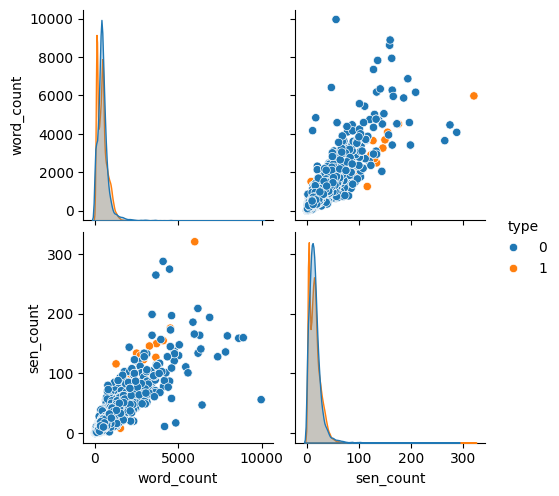

In [13]:
sns.pairplot(table,hue='type')
plt.show()

# stemming the title and the text

In [14]:
from nltk.stem.porter import PorterStemmer

def Stem_Clean_Text(text):
    ps = PorterStemmer()
    ans  = []
    for i in text.split():
        ans.append(ps.stem(i))
    return ' '.join(ans)

NewsTable = table.copy()
NewsTable['title'] = NewsTable['title'].apply(Stem_Clean_Text)
NewsTable['text'] = NewsTable['text'].apply(Stem_Clean_Text)


# merging title and text column 

In [15]:
NewsTable['text'] = NewsTable['title'] + NewsTable['text']

In [16]:
NewsTable = NewsTable.drop('title',axis=1)

In [17]:
NewsTable.head()

,text,subject,date,type,word_count,sen_count
0,"as u.s. budget fight looms, republican flip th...",politics,"December 31, 2017",1,885,30
1,u.s. militari to accept transgend recruit on m...,politics,"December 29, 2017",1,713,21
2,senior u.s. republican senator: 'let mr. muell...,politics,"December 31, 2017",1,523,17
3,fbi russia probe help by australian diplomat t...,politics,"December 30, 2017",1,437,16
4,trump want postal servic to charg 'much more' ...,politics,"December 29, 2017",1,987,40


# removing the stop words

In [ ]:
import nltk
from nltk.corpus import stopwords

@st.cache_resource
def load_stopwords():
    try:
        stopwords.words('english')
    except LookupError:
        nltk.download('stopwords')
    return stopwords.words('english')

STOPWORDS = load_stopwords()   # load once, make it a set (O(1) lookup)

def CleanText(text):
    return ' '.join([w for w in text.split() if w.lower() not in STOPWORDS])

NewsTable['text'] = NewsTable['text'].apply(CleanText)


# differentiate btw true and false news and make lists 

In [19]:
trueNews_corpus = []
fakeNews_corpus = []

for text in NewsTable[NewsTable['type']==1]['text'].tolist():
    for word in text.split():
        trueNews_corpus.append(word)

for text in NewsTable[NewsTable['type']==0]['text'].tolist():
    for word in text.split():
        fakeNews_corpus.append(word)

# watching most common words in true and fake news'es

In [20]:
from collections import Counter

most_common_in_true = pd.DataFrame(Counter(trueNews_corpus).most_common(30))
most_common_in_false = pd.DataFrame(Counter(fakeNews_corpus).most_common(30))

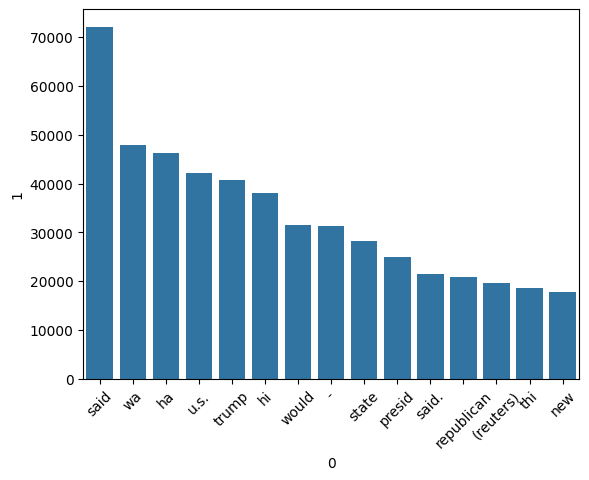

In [21]:
sns.barplot(data=most_common_in_true.head(15),x=0,y=1)
plt.xticks(rotation=45)
plt.show()

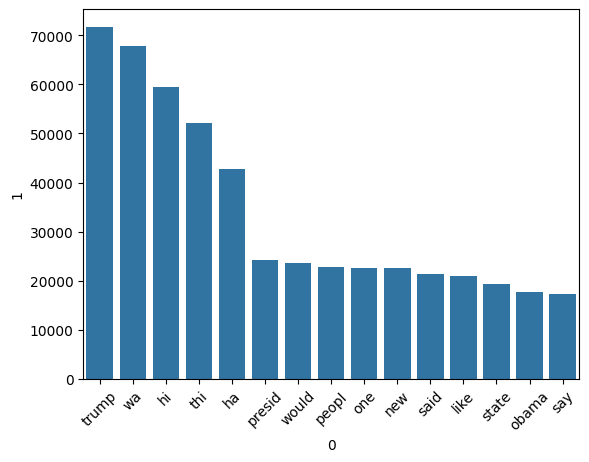

In [22]:
sns.barplot(data=most_common_in_false.head(15),x=0,y=1)
plt.xticks(rotation=45)
plt.show()

# **BUILDING MODEL**

**Using countvectorizer**

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer() # Convert a collection of text documents to a matrix of token counts.
x = cv.fit_transform(NewsTable['text'])
y = NewsTable['type']

In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [40]:
mnb.fit(x_train,y_train)
y_pred_train = mnb.predict(x_train)
y_pred_test = mnb.predict(x_test)

print(f'training accuracy : {accuracy_score(y_train,y_pred_train)*100}')
print(f'testing accuracy : {accuracy_score(y_test,y_pred_test)*100}')
print(confusion_matrix(y_test,y_pred_test))
print(precision_score(y_test,y_pred_test))

training accuracy : 96.83724038086753
testing accuracy : 96.38084632516704
[[4487  163]
 [ 162 4168]]
0.962364350034634


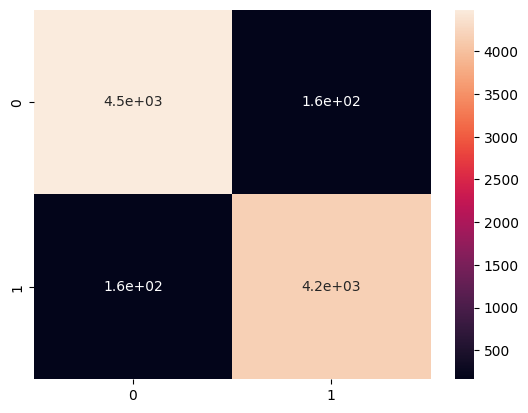

In [27]:
sns.heatmap(confusion_matrix(y_test,y_pred_test),annot=True)
plt.show()

**Using tfidfvectorizer**

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split

tf = TfidfVectorizer(max_features=50000)
X2 = tf.fit_transform(NewsTable['text'])
y2 = NewsTable['type']

X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f'training accuracy : {accuracy_score(y_train,y_pred_train)*100}')
print(f'testing accuracy : {accuracy_score(y_test,y_pred_test)*100}')
print(confusion_matrix(y_test,y_pred_test))
print(precision_score(y_test,y_pred_test))


training accuracy : 95.11665460214934
testing accuracy : 94.5879732739421
[[4406  195]
 [ 291 4088]]
0.9544711650712118


# Downloading the model

In [42]:
import pickle

pickle.dump(cv,open('CountVectorizer_nws.pkl','wb'))
pickle.dump(mnb,open('Model-nws.pkl','wb'))

# **testing the model**

In [41]:
new_text = ["Breaking: New report says economy recovered sharply."]

new_vec = cv.transform(new_text)  # DON'T FIT AGAIN!

prediction = mnb.predict(new_vec)

print("Prediction:", prediction[0])

Prediction: 0


In [49]:
NewsTable[NewsTable['type']==0].head()

,text,subject,date,type,word_count,sen_count
21417,donald trump send embarrass new year’ eve mess...,News,"December 31, 2017",0,599,28
21418,drunk brag trump staffer start russian collus ...,News,"December 31, 2017",0,331,11
21419,sheriff david clark becom internet joke threat...,News,"December 30, 2017",0,689,25
21420,trump obsess even ha obama’ name code hi websi...,News,"December 29, 2017",0,519,15
21421,pope franci call donald trump dure hi christma...,News,"December 25, 2017",0,458,19
